In [1]:
import pandapower as pp
import pandapower.networks as pn
import pandapower.plotting as plot
import pandapower.plotting.geo as pgeo
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import networkx as nx
import pandapower.networks as pn

500


C:\Users\Diem\AppData\Local\Temp\ipykernel_2560\4267753718.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


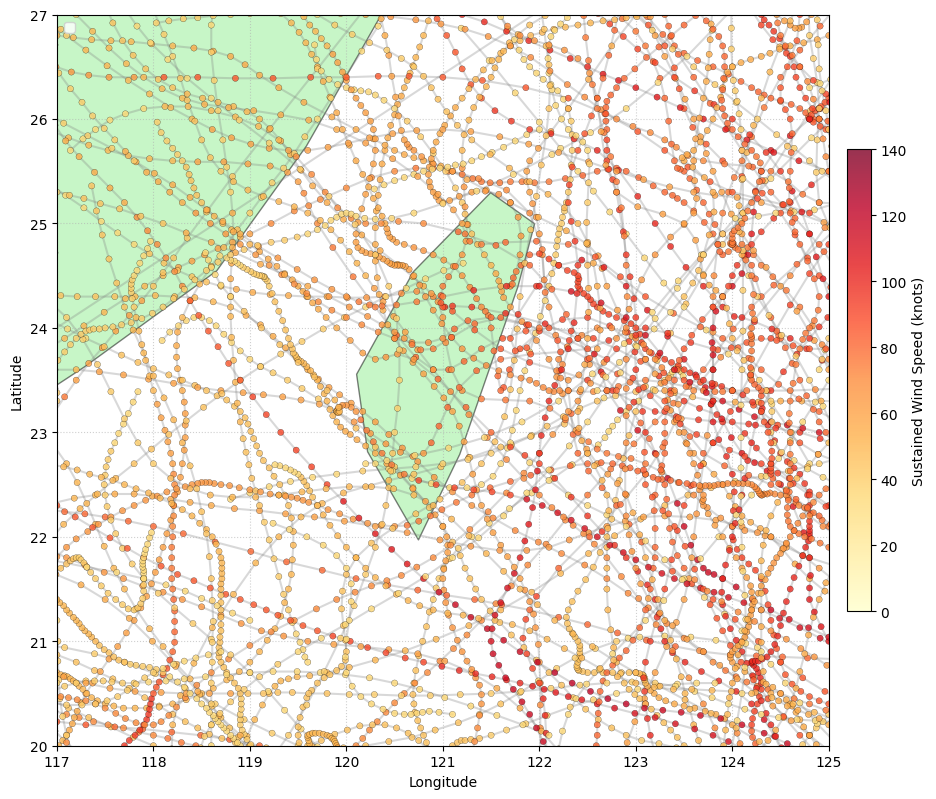

In [2]:
# ==============================================================================
# 2. LOAD AND PREPARE THE TYPHOON DATA (LAST 30)
# ==============================================================================
# Load your JMA dataset
df_typhoon = pd.read_csv('raw/typhoon_data.csv')


last_30_ids = df_typhoon['seq_id'].unique()[-500:]
print(len(last_30_ids))

# ==============================================================================
# 3. GEOGRAPHICAL PLOTTING (TAIWAN REGION)
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 10))

# A. Draw the Base Map
# We fetch the countries directly from Natural Earth
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.columns = world.columns.str.lower()
# Plot only Asia to save rendering memory
asia = world[world['continent'] == 'Asia']
asia.plot(ax=ax, color='lightgreen', edgecolor='black', alpha=0.5)

# B. Plot the Last 30 Typhoon Tracks
# We loop through the IDs to draw them as distinct tracks
for seq in last_30_ids:
    # Filter for the specific storm and remove genesis/dissipation (0 wind) stages
    track = df_typhoon[(df_typhoon['seq_id'] == seq) & (df_typhoon['wind'] > 0)].copy()
    
    if len(track) > 1:
        # Draw the continuous path line (slightly transparent gray)
        ax.plot(track['lng'], track['lat'], color='gray', linewidth=1.5, alpha=0.3, zorder=1)
        
        # Overlay the individual data points colored by wind intensity
        # We set vmin/vmax so the color scale is consistent across all 30 storms
        scatter = ax.scatter(track['lng'], track['lat'], c=track['wind'], cmap='YlOrRd', 
                             s=20, edgecolor='black', linewidth=0.2, alpha=0.8, zorder=2,
                             vmin=df_typhoon['wind'].min(), vmax=df_typhoon['wind'].max())
        
# ==============================================================================
# 4. FORMATTING, CROP, AND DISPLAY
# ==============================================================================
# Add a colorbar for the typhoon wind speeds
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Sustained Wind Speed (knots)')

# ---> THE CROP (Zooming in on Taiwan) <---
# This forces matplotlib to ignore the rest of Asia and frame Taiwan perfectly
ax.set_xlim(117.0, 125.0)  # Longitude bounds
ax.set_ylim(20.0, 27.0)    # Latitude bounds

# ax.set_title("Historical Tracks of the Last 30 Typhoons Approaching Taiwan", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper left')

plt.show()